# K_99 – Kombinierte Simulation

**Grid-Arbitrage** · Batteriespeicher-Arbitrage im Schweizer Strommarkt (Kür)

**Gruppe:** SC26_Gruppe_2 | **Verantwortlich:** Patrik Neunteufel | **Datum:** März 2026

---

*Hybrid-[Dispatch](../organisation/O_02_Glossar.ipynb#g-dispatch): Arbitrage + Eigenverbrauch kombiniert — 4-Strategie-Vergleich.*


| [← K_10 – Produktsteckbrief](K_10_Produkt_Steckbrief.ipynb) | [↑ Übersicht ↑](../organisation/O_01_Project_Overview.ipynb) | [K_00 – Business Strategy →](K_00_Business_Strategy.ipynb) |
|:---|:---:|---:|

## Inhaltsverzeichnis<a id='toc_K_99'></a>

[Einleitung](#einleitung_K_99)  
[Initialisierung](#initialisierung_K_99)  
1 [Hybrid-Dispatch Simulation](#hybrid-dispatch-simulation_K_99)  
2 [Visualisierungen für K_00](#visualisierungen-fuer-k00_K_99)  
3 [CAPEX-Szenarien: Was bringt sinkender Systempreis?](#capex-szenarien-was-bringt-sinkender-systempreis_K_99)  
4 [Abschlusskontrolle & K_00-Referenz](#abschlusskontrolle-k00-referenz_K_99)  
[Fazit](#fazit_K_99)  
[Abschluss](#abschluss_K_99)  


---
## Einleitung <a id='einleitung_K_99'></a>

[↑ Inhaltsverzeichnis](#toc_K_99)

Kombinierte End-to-End-Simulation als Synthese der Einzelanalysen:

- **Hybrid-Dispatch** — Arbitrage (Grosshandelspreise) + Eigenverbrauch
  (Niedertarif/Hochtarif) parallel auf derselben Batterie
- **CAPEX-Szenarien** — Auswirkung sinkender Systempreise auf Break-Even
  (Basis, optimistisch, pessimistisch)
- **K_00-Referenzen** — alle Charts und Kennzahlen, die in der Business
  Strategy verwendet werden, werden hier erzeugt und validiert

Das Notebook führt alle Pflicht- und Kür-Analysen zusammen und schreibt die
finalen Transfer-Kennzahlen nach `../sync/transfer.json`.


## Initialisierung<a id='initialisierung_K_99'></a>

[↑ Inhaltsverzeichnis](#toc_K_99)

Bibliotheken laden, `../sync/config.json` lesen, Verzeichnispfade setzen.

**Imports und Versionen:**

In [1]:
# ── lib/ aus Projekt-Root erreichbar machen + lib-Imports ───────────────────
# Notebook liegt in einem Unterordner (kuer/, experimental/, notebooks/,
# organisation/). Damit 'from lib.xxx import ...' funktioniert, muss der
# Projekt-Root vorne in sys.path stehen. autoreload sorgt dafür, dass
# Änderungen in lib/*.py ohne Kernel-Restart übernommen werden.
import sys, os
_PROJECT_ROOT = os.path.abspath('..')
if _PROJECT_ROOT not in sys.path:
    sys.path.insert(0, _PROJECT_ROOT)
try:
    get_ipython().run_line_magic('load_ext', 'autoreload')
    get_ipython().run_line_magic('autoreload', '2')
except Exception:
    pass

# lib-Imports (einmal zentral — in allen folgenden Zellen verfügbar)
from lib.plotting import show_source
from lib.io_ops   import load_transfer, save_transfer, final_check

print(f'lib-Pfad aktiv: {_PROJECT_ROOT}/lib')


lib-Pfad aktiv: C:\Users\patri\Documents\docker\python\OWN\Grid-Arbitrage/lib


In [2]:
# -- Setup ------------------------------------------------------------------
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
warnings.filterwarnings("ignore")
from datetime import datetime

# Versionen anzeigen für Reproduzierbarkeit
print(f"Numpy        Version: {np.__version__}")
print(f"Pandas       Version: {pd.__version__}")
print(f"📅 Zuletzt ausgeführt am: {datetime.now().strftime('%d.%m.%Y um %H:%M:%S')}")


Numpy        Version: 2.2.6
Pandas       Version: 2.3.3
📅 Zuletzt ausgeführt am: 26.04.2026 um 21:38:08


**Setup – Konfiguration & Verzeichnisstruktur:** Lädt `../sync/config.json` (SSOT), setzt Pfade.

**🔎 Quellcode der importierten lib-Funktion**

Die Funktion `load_transfer` wird aus `lib/io_ops.py` importiert und
liest Einträge aus `sync/transfer.json`. Aufklappbar ist der Quellcode einsehbar.


In [3]:
show_source(load_transfer)


<details>
<summary>🔎 Quellcode: <code>load_transfer</code> (aus <code>lib/io_ops.py</code>)</summary>

```python
def load_transfer(path='../sync/transfer.json', key=None, default=None):
    """Lädt transfer.json und gibt das ganze Dict oder einen Teil zurück.

    Verhalten
    ---------
    * Datei existiert nicht oder ist leer → Rückgabe ist ``default`` (bei
      key=None: ``default`` oder ``{}``). Gibt Warnung auf stdout aus.
    * Datei existiert → gibt bei ``key=None`` das ganze Dict zurück, bei
      gegebenem ``key`` nur den entsprechenden Teilbaum (``default``, wenn
      Key fehlt).

    Parameter
    ---------
    path : str, default '../sync/transfer.json'
        Pfad zur transfer.json.
    key : str, optional
        Top-Level-Key ('datenzeitraum', 'simulation', ...). Bei None wird
        das komplette Dict zurückgegeben.
    default : any, optional
        Rückgabewert bei fehlender Datei oder fehlendem Key. Bei key=None
        ist der Default ``{}``.

    Return
    ------
    dict oder der Wert des angefragten Keys.
    """
    import json as _json

    if default is None and key is None:
        default = {}

    if not os.path.exists(path) or os.path.getsize(path) == 0:
        print(f'⚠️  {path} nicht gefunden oder leer — NB01/NB02 zuerst ausführen')
        return default

    with open(path, encoding='utf-8') as _f:
        data = _json.load(_f)

    if key is None:
        return data
    return data.get(key, default)
```

</details>


In [4]:
with open('../sync/config.json') as _f:
    CFG = json.load(_f)

MODE         = CFG["mode"]
EUR_CHF      = CFG.get("eur_chf", 0.97)
SZ_AKTIV     = CFG["szenarien"]["gleichzeitigkeit_aktiv"]
FORCE_RELOAD = CFG.get('force_reload', {})  # konventionskonform gelesen
# ── Farben & Stil aus ../sync/config.json (SSOT) ─────────────────────────────────────
# Bestehende Variablen (Rückwärtskompatibilität)


In [5]:
CHARTS_DIR   = os.path.join('../output', 'charts', SZ_AKTIV)
os.makedirs(CHARTS_DIR, exist_ok=True)
DPI = CFG['visualisierung']['output_dpi']  # SSOT: ../sync/config.json

_sim          = CFG["pflicht"]["simulation"]
_w            = CFG["pflicht"]["wirtschaftlichkeit"]
CHARGE_Q      = _sim["charge_quantile"]
DISCHARGE_Q   = _sim["discharge_quantile"]
SOC_MIN       = _sim["soc_min_pct"]
SOC_MAX       = _sim["soc_max_pct"]
EFFICIENCY    = _sim["efficiency_roundtrip"]
CAPEX_EUR_KWH = _w["capex_eur_kwh"]
OPEX_RATE     = _w["opex_rate"]
LIFETIME      = _w["lifetime_j"]
ZIEL_ROI      = round(100 / LIFETIME, 2)  # Ziel-ROI = 1/lifetime_j: ROI der nötig ist, um BE in LIFETIME Jahren zu erreichen

HT_PREIS = 0.30 * EUR_CHF
NT_PREIS = 0.22 * EUR_CHF


In [6]:
_viz        = CFG.get('visualisierung', {}).get('farben', {})
BG_DARK     = _viz.get('bg_dark',    '#0d1117')
BG_PANEL    = _viz.get('bg_panel',   '#141414')
C_PRICE     = _viz.get('c_price',    '#FFA726')
C_LOAD      = _viz.get('c_load',     '#66BB6A')
C_CHARGE    = _viz.get('c_charge',   '#1565C0')
C_FEED      = _viz.get('c_feed',     '#B71C1C')
SEG_COLORS  = _viz.get('seg_colors', ['#42A5F5', '#66BB6A', '#FFA726', '#EF5350'])
C_PRIV, C_GEW, C_IND, C_UTIL = SEG_COLORS

# UI-Strukturfarben
C_ACHSE      = _viz.get('c_achse',      '#aaaaaa')  # Achsenbeschriftungen
C_TICK       = _viz.get('c_tick',       '#bbbbbb')  # Tick-Labels
C_SPINE      = _viz.get('c_spine',      '#333333')  # Achsenrahmen
C_LEGENDE_BG = _viz.get('c_legende_bg', '#111111')  # Legenden-Hintergrund
C_GITTER     = _viz.get('c_gitter',     '#cccccc')  # Gitterlinien

# Funktionale Extrafarben (nur laden was das NB braucht)
C_DISPATCH   = _viz.get('c_dispatch',   '#AB47BC')  # Dispatch-optimal
C_STACKING   = _viz.get('c_stacking',   '#5DCAA5')  # Revenue Stacking
C_SOLAR      = _viz.get('c_solar',      '#FDD835')  # Solar-Ertrag
C_GRENZWERT  = _viz.get('c_amber_dark', '#FF6F00')  # Grenzwert / Warnung
C_CYAN       = _viz.get('c_cyan',       '#26C6DA')  # Flusswasser / Alt. Speicher
C_GRUEN_DARK = _viz.get('c_gruen_dark', '#388E3C')  # Erneuerbare

# Stilkonstanten
_stil               = CFG.get('visualisierung', {}).get('stil', {})
LW                  = _stil.get('linienbreite_standard', 1.5)   # Standard-Linienbreite
LW_DUENN            = _stil.get('linienbreite_duenn',    0.8)   # dünne Linien
LW_DICK             = _stil.get('linienbreite_dick',     2.5)   # dicke Linien
ALPHA_FLAECHE       = _stil.get('alpha_flaeche',         0.12)  # dezente Füllung
ALPHA_FLAECHE_STARK = _stil.get('alpha_flaeche_stark',   0.35)  # Balken / Füllung
ALPHA_LEGENDE       = _stil.get('alpha_legende',         0.30)  # Legenden-BG
ALPHA_GEDAEMPFT     = _stil.get('alpha_linie_gedaempft', 0.55)  # Nebenlinien
FS_TITEL            = _stil.get('schriftgroesse_titel',   13)   # Chart-Titel
FS_ACHSE            = _stil.get('schriftgroesse_achse',   10)   # Achsenbeschr.
FS_TICK             = _stil.get('schriftgroesse_tick',     9)   # Ticks
FS_LEGENDE          = _stil.get('schriftgroesse_legende',  8)   # Legende
FS_KLEIN            = _stil.get('schriftgroesse_klein',    7)   # Annotationen

# matplotlib rcParams — nur stabile, versionsunabhängige Keys (matplotlib >= 3.5)
# axes.titlecolor (3.8+) und axes.grid (stört Karten) bewusst NICHT gesetzt
import matplotlib as mpl
mpl.rcParams.update({
    'figure.facecolor':  BG_DARK,
    'axes.facecolor':    BG_PANEL,
    'axes.edgecolor':    C_SPINE,
    'axes.labelcolor':   C_ACHSE,
    'axes.labelsize':    FS_ACHSE,
    'axes.titlesize':    FS_TITEL,
    'xtick.color':       C_TICK,
    'ytick.color':       C_TICK,
    'xtick.labelsize':   FS_TICK,
    'ytick.labelsize':   FS_TICK,
    'text.color':        'white',
    'lines.linewidth':   LW,
    'legend.facecolor':  C_LEGENDE_BG,
    'legend.framealpha': ALPHA_LEGENDE,
    'legend.fontsize':   FS_LEGENDE,
    'legend.edgecolor':  C_SPINE,
})
print('Farben & Stil geladen.')

C_ARB   = C_PRICE
C_EV    = C_LOAD
C_HYB   = C_PRIV
C_HYBOP = C_DISPATCH

SEGMENTS = {
    "Privat_10kWh":   {"cap_kwh": 10,    "pow_kw": 5,    "capex_key": "Privat_10kWh"},
    "Gewerbe_100kWh": {"cap_kwh": 100,   "pow_kw": 30,   "capex_key": "Gewerbe_100kWh"},
    "Industrie_1MWh": {"cap_kwh": 1000,  "pow_kw": 200,  "capex_key": "Industrie_1MWh"},
    "Utility_10MWh":  {"cap_kwh": 10000, "pow_kw": 2000, "capex_key": "Utility_10MWh"},
}


Farben & Stil geladen.


In [7]:
# -- Transfer: Ergebnisse aus ../sync/transfer.json laden ----------------------------
TF        = load_transfer()
_dt       = TF.get('datenzeitraum', {})
_sim_tf   = TF.get('simulation', {})
TF_N_YEARS = _dt.get('n_years', None)
TF_START   = _dt.get('start_date', 'unbekannt')
TF_END     = _dt.get('end_date',   'unbekannt')
TF_SPREAD  = _sim_tf.get('spread_mean_eur_mwh', None)
TF_ECON    = _sim_tf.get('wirtschaftlichkeit', {})
TF_HYB     = TF.get('hybrid_simulation', {}).get('ergebnisse', {})
if TF:
    print(f"../sync/transfer.json: {TF_START} – {TF_END} ({TF_N_YEARS} Jahre)")

print(f"Setup OK | Szenario={SZ_AKTIV} | Charts → {CHARTS_DIR}")


../sync/transfer.json: 2023 – 2026 (3.32 Jahre)
Setup OK | Szenario=realistisch | Charts → ../output\charts\realistisch


**⚙ Markdown-Prüfwerte (config-abhängig) und 📊 Markdown-Prüfwerte (transfer-abhängig)**:  
Werte mit ⚙ kommen aus `../sync/config.json`, Werte mit 📊 aus `../sync/transfer.json` (NB03 + frühere Kür-NBs).  
Bei jeder Änderung dieser Quellen → Output mit ⚙/📊-Stellen im Markdown abgleichen.


In [8]:
# ── ⚙ Markdown-Prüfwerte (config-abhängig) ─────────────────────────────────
print('=== ⚙ MARKDOWN-PRÜFWERTE (config-abhängig) ===')
_pflicht = CFG['pflicht']['simulation']
_wirt    = CFG['pflicht']['wirtschaftlichkeit']
_markt   = CFG['kuer']['markt']
print(f'  Round-Trip-Effizienz   = {_pflicht["efficiency_roundtrip"]*100:.0f} %')
print(f'  SoC-Bereich            = {_pflicht["soc_min_pct"]*100:.0f} – {_pflicht["soc_max_pct"]*100:.0f} %')
print(f'  Lebensdauer            = {_wirt["lifetime_j"]} Jahre')
print(f'  OPEX-Rate              = {_wirt["opex_rate"]*100:.1f} % p.a.')
print(f'  CAPEX-Trigger Privat   = {_markt["capex_ziel_privat_eur_kwh"]} EUR/kWh')
print(f'  CAPEX-Lernrate         = {_markt["capex_lernrate_pct_pro_jahr"]} %/Jahr')


=== ⚙ MARKDOWN-PRÜFWERTE (config-abhängig) ===
  Round-Trip-Effizienz   = 92 %
  SoC-Bereich            = 5 – 95 %
  Lebensdauer            = 12 Jahre
  OPEX-Rate              = 1.5 % p.a.
  CAPEX-Trigger Privat   = 250 EUR/kWh
  CAPEX-Lernrate         = 10 %/Jahr


In [9]:
# ── 📊 Markdown-Prüfwerte (transfer-abhängig) ──────────────────────────────
_tf_dz  = TF.get('datenzeitraum', {})
_tf_ec  = TF.get('simulation', {}).get('wirtschaftlichkeit', {})
_tf_ev  = TF.get('eigenverbrauch', {})
_tf_hyb = TF.get('hybrid_simulation', {}).get('ergebnisse', {})
print('=== 📊 MARKDOWN-PRÜFWERTE (transfer-abhängig) ===')
print(f'  Datenzeitraum                 = {_tf_dz.get("start_date","?")} bis {_tf_dz.get("end_date","?")} ({_tf_dz.get("n_years","?")}J)')
print(f'  Arbitrage-Only ROI je Segment (NB03):')
for _seg, _v in _tf_ec.items():
    print(f'    {_seg:<22}: ROI {_v.get("roi_pct","?"):>5.2f} % | Payback {_v.get("payback_years","?"):>5.1f}J')
print(f'  Eigenverbrauch-ROI Privat (K_09): {_tf_ev.get("roi_ev_privat_pct","?")} %/J')
if _tf_hyb:
    print(f'  Hybrid-ROI (existiert von früherem Run):')
    for _seg, _v in _tf_hyb.items():
        print(f'    {_seg:<22}: Hyb {_v.get("roi_hyb","?"):>4.1f}% | Hyb-Opt {_v.get("roi_hybo","?"):>4.1f}%')
else:
    print(f'  (hybrid_simulation noch nicht in transfer.json — wird in Cell unten geschrieben)')


=== 📊 MARKDOWN-PRÜFWERTE (transfer-abhängig) ===
  Datenzeitraum                 = 2023 bis 2026 (3.32J)
  Arbitrage-Only ROI je Segment (NB03):
    Privat_10kWh          : ROI  1.80 % | Payback  55.6J
    Gewerbe_100kWh        : ROI  3.14 % | Payback  31.8J
    Industrie_1MWh        : ROI  4.58 % | Payback  21.8J
    Utility_10MWh         : ROI  2.97 % | Payback  33.6J
  Eigenverbrauch-ROI Privat (K_09): 3.75 %/J
  Hybrid-ROI (existiert von früherem Run):
    Privat_10kWh          : Hyb  2.3% | Hyb-Opt  2.2%
    Gewerbe_100kWh        : Hyb  1.4% | Hyb-Opt  1.2%
    Industrie_1MWh        : Hyb  1.2% | Hyb-Opt  1.0%
    Utility_10MWh         : Hyb  1.3% | Hyb-Opt  1.1%


---
### Daten laden

Spot-Preise aus `data/processed/` und Transfer-Daten aus NB02/K_09/K_10 laden;
Existenzprüfung aller Eingabedateien vor Simulationsstart.


In [10]:
# -- Preisdaten laden --------------------------------------------------------
DIR_PROC  = os.path.join("../data", "processed")
DIR_INTER = os.path.join("../data", "intermediate", SZ_AKTIV)

prices_file = os.path.join(DIR_PROC, "ch_spot_prices_clean.csv")
econ_file   = os.path.join(DIR_INTER, "wirtschaftlichkeit.csv")

if os.path.exists(prices_file):
    df_p = pd.read_csv(prices_file, parse_dates=["timestamp"])
    df_p["timestamp"] = pd.to_datetime(df_p["timestamp"], utc=True)
    df_p["hour"]  = df_p["timestamp"].dt.hour
    df_p["month"] = df_p["timestamp"].dt.month
    prices  = df_p["price_eur_mwh"].values
    # T3-Fix: n_years primär aus ../sync/transfer.json (NB01 SSOT) — vermeidet Drift
    n_years_calc = len(df_p) / 8760
    if TF_N_YEARS:
        if abs(n_years_calc - TF_N_YEARS) > 0.05:
            print(f'⚠️  n_years Abweichung: K_99={n_years_calc:.3f} vs NB01={TF_N_YEARS:.3f}')
        n_years = TF_N_YEARS  # SSOT: NB01 via ../sync/transfer.json
    else:
        n_years = n_years_calc
        print(f'⚠️  TF_N_YEARS fehlt — NB01 zuerst ausführen')
    hour_arr = df_p["hour"].values
    REAL_DATA = True
    print(f"Preisdaten: {len(df_p):,} Stunden | n_years={n_years:.3f} (aus ../sync/transfer.json)")
    print(f"  Spread (p75-p25): {np.percentile(prices,75)-np.percentile(prices,25):.1f} EUR/MWh")
else:
    print("WARNING: Preisdaten nicht gefunden -- NB01 zuerst ausfuehren.")
    print("  Verwende synthetisches Profil fuer Demonstration.")
    np.random.seed(42)
    n_h = 8760 * 2
    hour_arr = np.tile(np.arange(24), n_h // 24 + 1)[:n_h]
    prices = np.clip(80 + 15*np.sin(2*np.pi*hour_arr/24 - np.pi/2)
                     + 10*np.random.randn(n_h), -50, 300)
    n_years = TF_N_YEARS if TF_N_YEARS else 2  # aus ../sync/transfer.json (NB01)
    REAL_DATA = False

is_nt = (hour_arr >= 20) | (hour_arr < 8)

# Arbitrage-Basiswerte aus NB02
if os.path.exists(econ_file):
    df_econ = pd.read_csv(econ_file)
    ARB_ROI = dict(zip(df_econ["segment"], df_econ["roi_pct"]))
    ARB_NET = dict(zip(df_econ["segment"], df_econ["net_annual"]))
else:
    ARB_ROI = {"Privat_10kWh": 0.6, "Gewerbe_100kWh": 1.4,
               "Industrie_1MWh": 2.3, "Utility_10MWh": 1.3}
    ARB_NET = {k: SEGMENTS[k]["cap_kwh"]*CAPEX_EUR_KWH[SEGMENTS[k]["capex_key"]]*v/100
               for k, v in ARB_ROI.items()}
    print("  Fallback: ROI-Werte aus NB02-Output")

print(f"Arbitrage-Only ROI: { {k: f'{v:.1f}%' for k,v in ARB_ROI.items()} }")


Preisdaten: 29,087 Stunden | n_years=3.320 (aus ../sync/transfer.json)
  Spread (p75-p25): 47.6 EUR/MWh
Arbitrage-Only ROI: {'Privat_10kWh': '1.8%', 'Gewerbe_100kWh': '3.1%', 'Industrie_1MWh': '4.6%', 'Utility_10MWh': '3.0%'}


---
## 1. Hybrid-Dispatch Simulation <a id='hybrid-dispatch-simulation_K_99'></a>

[↑ Inhaltsverzeichnis](#toc_K_99)

### Dispatch-Logik

```
Arbitrage-Only:   Laden bei Preis < p25(Tag), Einspeisen bei Preis > p75(Tag)
Eigenverbrauch:   NT laden (20-08h + WE), HT selbst nutzen -- kein Einspeisen
Hybrid statisch:  EV_FRAC x Kapazitaet reserviert fuer EV; Rest fuer Arbitrage
Hybrid optimiert: EV_FRAC taeglich angepasst basierend auf Spread-Niveau
```


In [11]:
# -- Simulationsfunktionen -------------------------------------------------
# Hinweis: Arbitrage-Only-Kennzahlen kommen direkt aus NB03 via Transfer
# (ARB_NET/ARB_ROI dicts in Cell 10). Eine lokale Arbitrage-Sim hier wäre
# redundant und würde Datenperioden-Abweichungen riskieren (siehe Kommentar
# unten in der Simulations-Schleife). Deshalb nur sim_ev und sim_hybrid.
# Für die Arbitrage-Sim siehe lib/simulation.simulate_battery_dispatch.
EV_FRAC_STATIC  = 0.70   # Anteil Kapazitaet fuer EV reserviert
VERBRAUCH_TAG   = 10.0   # kWh/Tag (Privat-Referenz)

def sim_ev(cap_kwh, pow_kw, verbrauch_j, n_years):
    """NT laden (nur was HT-Bedarf erfordert), HT Eigenverbrauch."""
    n = len(is_nt); soc = 0.5; total = 0.0
    v_h = verbrauch_j / (365*n_years*24)
    # Maximaler Tagesbedarf HT (12h Fenster)
    v_day_ht = min(12*v_h, (SOC_MAX-SOC_MIN)*cap_kwh)
    for d in range(n // 24):
        soc_target = min(SOC_MAX, SOC_MIN + v_day_ht/cap_kwh)
        for h in range(24):
            idx = d*24 + h; nt = is_nt[idx]
            if nt and soc < soc_target:
                e = min(pow_kw, (soc_target-soc)*cap_kwh/EFFICIENCY)
                soc += e*EFFICIENCY/cap_kwh; total -= e*NT_PREIS
            elif not nt and soc > SOC_MIN:
                bed = min(v_h, (soc-SOC_MIN)*cap_kwh)
                soc -= bed/cap_kwh; total += bed*HT_PREIS
    return total / n_years

def sim_hybrid(prices, cap_kwh, pow_kw, verbrauch_j, n_years, optimized=False):
    """Zwei virtuelle Partitionen:
    - EV-Partition  (cap_kwh * frac):       Haushalt-Tarife NT/HT
    - Arb-Partition (cap_kwh * (1-frac)):   Spot-Preise p25/p75
    Jede Partition hat eigenen SOC [SOC_MIN..SOC_MAX].
    """
    n = len(prices); v_h = verbrauch_j / (365*n_years*24)
    soc_ev = 0.5; soc_arb = 0.5; total = 0.0
    for d in range(n // 24):
        dp = prices[d*24:(d+1)*24]
        pL = np.percentile(dp, CHARGE_Q*100)
        pH = np.percentile(dp, DISCHARGE_Q*100)
        spread = pH - pL
        if optimized:
            frac = float(np.clip(0.80 - (spread-20)/300, 0.40, 0.85))
        else:
            frac = EV_FRAC_STATIC
        cap_ev  = cap_kwh * frac;       cap_arb = cap_kwh * (1-frac)
        pow_ev  = pow_kw  * frac;       pow_arb = pow_kw  * (1-frac)
        v_day_ht = min(12*v_h, (SOC_MAX-SOC_MIN)*cap_ev) if cap_ev > 0 else 0
        soc_ev_target = min(SOC_MAX, SOC_MIN + v_day_ht/cap_ev) if cap_ev > 0 else SOC_MAX
        for h in range(24):
            idx = d*24 + h; price = prices[idx]
            nt = is_nt[idx % len(is_nt)]
            # EV-Partition: Haushalt-Tarif
            if cap_ev > 0:
                if nt and soc_ev < soc_ev_target:
                    e = min(pow_ev, (soc_ev_target-soc_ev)*cap_ev/EFFICIENCY)
                    soc_ev += e*EFFICIENCY/cap_ev; total -= e*NT_PREIS
                elif not nt and soc_ev > SOC_MIN:
                    bed = min(v_h, (soc_ev-SOC_MIN)*cap_ev)
                    soc_ev -= bed/cap_ev; total += bed*HT_PREIS
            # Arb-Partition: Spot-Preise
            if cap_arb > 0:
                mxC = min(pow_arb, (SOC_MAX-soc_arb)*cap_arb/EFFICIENCY)
                mxD = min(pow_arb, (soc_arb-SOC_MIN)*cap_arb)
                if price <= pL and soc_arb < SOC_MAX and mxC > 0:
                    e = min(mxC, pow_arb); soc_arb += e*EFFICIENCY/cap_arb
                    total -= e*price/1000
                elif price >= pH and soc_arb > SOC_MIN and mxD > 0:
                    e = min(mxD, pow_arb); soc_arb -= e/cap_arb
                    total += e*price/1000
    return total / n_years

# -- Alle Segmente simulieren -------------------------------------------------
# Arbitrage-Only: direkt aus NB02-wirtschaftlichkeit.csv (SSOT)
# So bleiben Chart 1b (NB02) und der Arb-Balken hier konsistent.
# EV, Hybrid: K_99-Simulation auf denselben Preisdaten.
results = {}
for seg, p in SEGMENTS.items():
    cap  = p["cap_kwh"]; pow_ = p["pow_kw"]
    capex = cap * CAPEX_EUR_KWH[p["capex_key"]]
    opex  = capex * OPEX_RATE
    verbrauch = VERBRAUCH_TAG * 365 * n_years * (cap/10)**0.55
    # Arbitrage-Only aus NB02 (vermeidet Datenperioden-Abweichung)
    arb_net = ARB_NET.get(seg, 0)   # netto EUR/Jahr aus wirtschaftlichkeit.csv
    arb_roi = ARB_ROI.get(seg, 0)   # ROI % aus wirtschaftlichkeit.csv
    arb_be  = capex / arb_net if arb_net > 0 else float('inf')
    # EV und Hybrid: eigene Simulation
    ev    = sim_ev(cap, pow_, verbrauch, n_years)
    hyb   = sim_hybrid(prices, cap, pow_, verbrauch, n_years, False)
    hybo  = sim_hybrid(prices, cap, pow_, verbrauch, n_years, True)
    def roi(net): return (net-opex)/capex*100 if capex>0 else 0
    def be(net): n=net-opex; return capex/n if n>0 else float('inf')
    results[seg] = dict(capex=capex, opex=opex,
        arb_j=arb_net, ev_j=ev, hyb_j=hyb, hybo_j=hybo,
        roi_arb=arb_roi, roi_ev=roi(ev), roi_hyb=roi(hyb), roi_hybo=roi(hybo),
        be_arb=arb_be,  be_ev=be(ev),   be_hyb=be(hyb),  be_hybo=be(hybo))

DMAX_SIM = int(LIFETIME * 2.5)  # Anzeigedeckel für Tabelle
def fmt_be(v, lim=None): lim=lim or DMAX_SIM; return f">{lim}J" if v > lim else f"{v:.0f}J"

print(f"{'Segment':<22} {'Arb':>7} {'EV':>7} {'Hyb':>7} {'Hyb-Opt':>9}  "
      f"{'BE-Arb':>8} {'BE-Hyb':>8} {'BE-Opt':>8}")
print("-"*88)
for seg, r in results.items():
    print(f"{seg:<22} {r['roi_arb']:>6.1f}% {r['roi_ev']:>6.1f}% "
          f"{r['roi_hyb']:>6.1f}% {r['roi_hybo']:>8.1f}%  "
          f"{fmt_be(r['be_arb']):>8} {fmt_be(r['be_hyb']):>8} {fmt_be(r['be_hybo']):>8}")



Segment                    Arb      EV     Hyb   Hyb-Opt    BE-Arb   BE-Hyb   BE-Opt
----------------------------------------------------------------------------------------
Privat_10kWh              1.8%    1.2%    2.3%      2.2%      >30J     >30J     >30J
Gewerbe_100kWh            3.1%   -0.2%    1.4%      1.2%      >30J     >30J     >30J
Industrie_1MWh            4.6%   -0.9%    1.2%      1.0%       22J     >30J     >30J
Utility_10MWh             3.0%   -1.2%    1.3%      1.1%      >30J     >30J     >30J


---
## 2. Visualisierungen für K_00 <a id='visualisierungen-fuer-k00_K_99'></a>

[↑ Inhaltsverzeichnis](#toc_K_99)

Fünf Charts für den Einbettung in K_00 (Business Strategy):
[ROI](../organisation/O_02_Glossar.ipynb#g-roi)-Vergleich, Break-Even, Nutzerverhalten-Sensitivität, Revenue Split und Kombi-Heatmap.


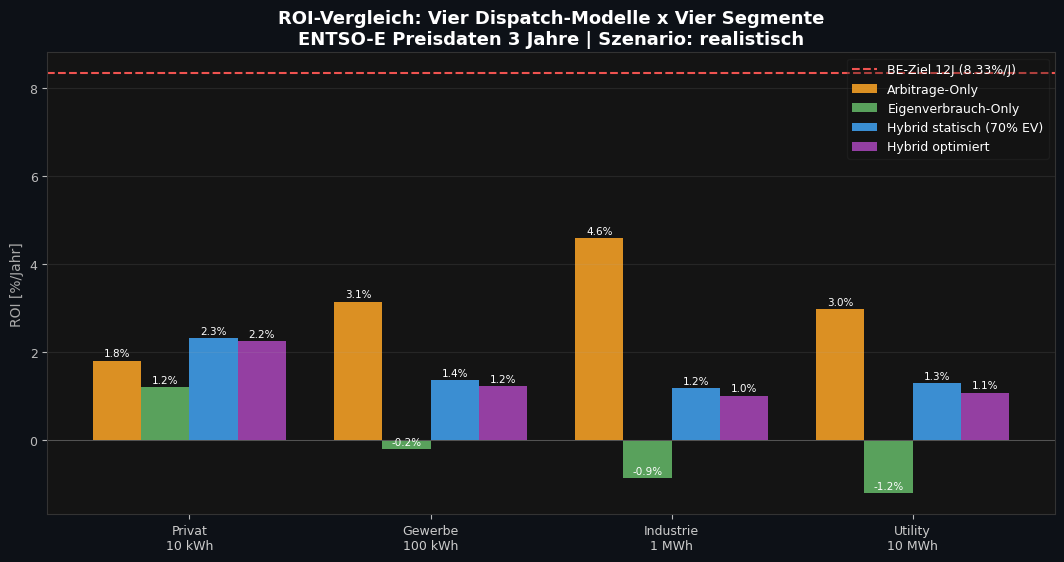

Gespeichert: ../output\charts\realistisch\kuer_k99_roi_vergleich.png


In [12]:
# -- Chart kuer_k99_roi_vergleich ------------------------------------------------
segs   = list(results.keys())
labels = ["Privat\n10 kWh","Gewerbe\n100 kWh","Industrie\n1 MWh","Utility\n10 MWh"]
models = [("roi_arb","Arbitrage-Only",C_ARB),
          ("roi_ev","Eigenverbrauch-Only",C_EV),
          (f"roi_hyb",f"Hybrid statisch ({EV_FRAC_STATIC:.0%} EV)",C_HYB),
          ("roi_hybo","Hybrid optimiert",C_HYBOP)]
x = np.arange(len(segs)); w = 0.2

fig, ax = plt.subplots(figsize=(13,6))
fig.patch.set_facecolor(BG_DARK); ax.set_facecolor(BG_PANEL)
ax.tick_params(colors=C_TICK)
for sp in ax.spines.values(): sp.set_edgecolor(C_SPINE)

for j,(key,label,col) in enumerate(models):
    vals = [results[s][key] for s in segs]
    bars = ax.bar(x+j*w-1.5*w, vals, w, label=label, color=col, alpha=0.85)
    for bar,v in zip(bars,vals):
        if abs(v)>0.05:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                    f"{v:.1f}%", ha="center", va="bottom", color="white", fontsize=7.5)

ax.axhline(ZIEL_ROI, color=C_UTIL, lw=LW, ls="--",
                   label=f"BE-Ziel {LIFETIME}J ({ZIEL_ROI}%/J)")
ax.axhline(0, color="#555", lw=0.7)
ax.set_xticks(x); ax.set_xticklabels(labels, color=C_GITTER)
ax.set_ylabel("ROI [%/Jahr]", color=C_ACHSE)
ax.set_title("ROI-Vergleich: Vier Dispatch-Modelle x Vier Segmente\n"
             f"ENTSO-E Preisdaten {int(n_years)} Jahre | Szenario: {SZ_AKTIV}",
             color="white", fontweight="bold")
ax.legend(fontsize=FS_TICK, framealpha=ALPHA_LEGENDE, facecolor=C_LEGENDE_BG, labelcolor="white")
ax.grid(True, axis="y", alpha=ALPHA_FLAECHE)
p = os.path.join(CHARTS_DIR,"kuer_k99_roi_vergleich.png")
plt.savefig(p, dpi=DPI, bbox_inches="tight", facecolor=BG_DARK)
plt.show(); plt.close(); print(f"Gespeichert: {p}")


**Chart kuer_k99_breakeven_vergleich:** Break-Even-Vergleich aller Strategien je Segment —
zeigt in welchem Jahr welche Kombination den Gesamt-[CAPEX](../organisation/O_02_Glossar.ipynb#g-capex) zurückverdient.


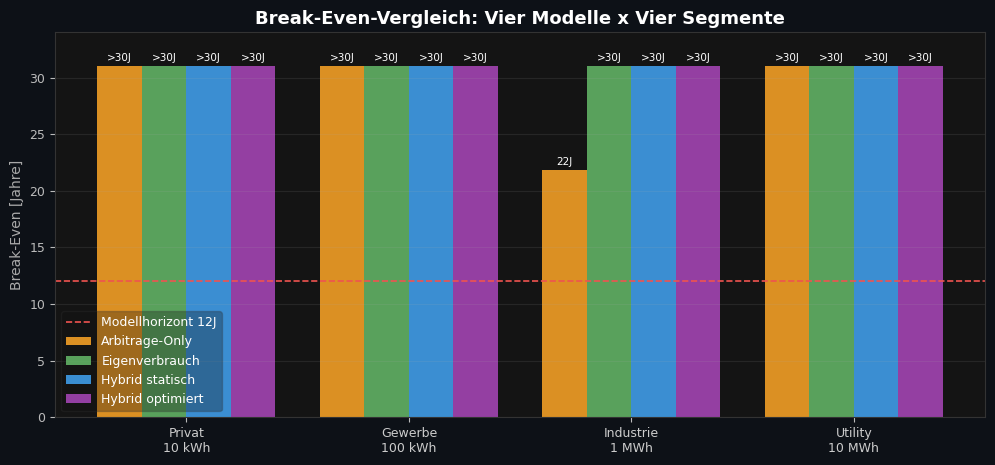

Gespeichert: ../output\charts\realistisch\kuer_k99_breakeven.png


In [13]:
# -- Chart kuer_k99_breakeven_vergleich ------------------------------------------
DMAX = int(LIFETIME * 2.5)   # Anzeigedeckel: 2.5 × Modellhorizont
fig, ax = plt.subplots(figsize=(12,5))
fig.patch.set_facecolor(BG_DARK); ax.set_facecolor(BG_PANEL)
ax.tick_params(colors=C_TICK)
for sp in ax.spines.values(): sp.set_edgecolor(C_SPINE)

for j,(key,label,col) in enumerate([("be_arb","Arbitrage-Only",C_ARB),
    ("be_ev","Eigenverbrauch",C_EV),("be_hyb","Hybrid statisch",C_HYB),
    ("be_hybo","Hybrid optimiert",C_HYBOP)]):
    vals = [min(results[s][key],DMAX+1) for s in segs]
    bars = ax.bar(x+j*w-1.5*w, vals, w, label=label, color=col, alpha=0.85)
    for bar,s in zip(bars,segs):
        v = results[s][key]
        txt = f">{DMAX}J" if v>DMAX else f"{v:.0f}J"
        ax.text(bar.get_x()+bar.get_width()/2, min(v,DMAX+1)+0.3,
                txt, ha="center", va="bottom", color="white", fontsize=7.5)

ax.axhline(LIFETIME, color=C_UTIL, lw=1.2, ls="--",
           label=f"Modellhorizont {LIFETIME}J")
ax.set_xticks(x); ax.set_xticklabels(labels, color=C_GITTER)
ax.set_ylabel("Break-Even [Jahre]", color=C_ACHSE)
ax.set_ylim(0, DMAX+4)
ax.set_title("Break-Even-Vergleich: Vier Modelle x Vier Segmente",
             color="white", fontweight="bold")
ax.legend(fontsize=FS_TICK, framealpha=ALPHA_LEGENDE, facecolor=C_LEGENDE_BG, labelcolor="white")
ax.grid(True, axis="y", alpha=ALPHA_FLAECHE)
p = os.path.join(CHARTS_DIR,"kuer_k99_breakeven.png")
plt.savefig(p, dpi=DPI, bbox_inches="tight", facecolor=BG_DARK)
plt.show(); plt.close(); print(f"Gespeichert: {p}")


**Chart kuer_k99_nutzerverhalten_sensitivity:** Sensitivitätsanalyse Eigenverbrauchsquote —
wie stark verändert sich der [ROI](../organisation/O_02_Glossar.ipynb#g-roi) wenn der Nutzer mehr/weniger selbst verbraucht?


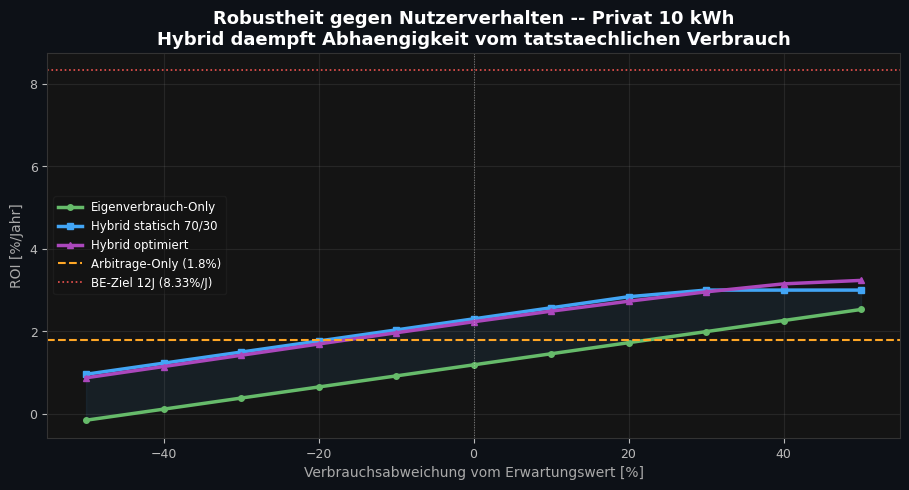

Gespeichert: ../output\charts\realistisch\kuer_k99_nutzerverhalten.png


In [14]:
# -- Chart kuer_k99_nutzerverhalten_sensitivity -----------------------------------
seg="Privat_10kWh"; cap=SEGMENTS[seg]["cap_kwh"]; pow_=SEGMENTS[seg]["pow_kw"]
capex=cap*CAPEX_EUR_KWH[SEGMENTS[seg]["capex_key"]]; opex=capex*OPEX_RATE
vbasis = VERBRAUCH_TAG*365*n_years
abw = np.linspace(0.5, 1.5, 11)
roi_ev_l, roi_hyb_l, roi_hybo_l = [], [], []
for fac in abw:
    v = vbasis*fac
    roi_ev_l.append((sim_ev(cap,pow_,v,n_years)-opex)/capex*100)
    roi_hyb_l.append((sim_hybrid(prices,cap,pow_,v,n_years,False)-opex)/capex*100)
    roi_hybo_l.append((sim_hybrid(prices,cap,pow_,v,n_years,True)-opex)/capex*100)

fig, ax = plt.subplots(figsize=(11,5))
fig.patch.set_facecolor(BG_DARK); ax.set_facecolor(BG_PANEL)
ax.tick_params(colors=C_TICK)
for sp in ax.spines.values(): sp.set_edgecolor(C_SPINE)
pct = (abw-1)*100
ax.plot(pct, roi_ev_l,   color=C_EV,    lw=LW_DICK, label="Eigenverbrauch-Only",       marker="o", ms=4)
ax.plot(pct, roi_hyb_l,  color=C_HYB,   lw=LW_DICK, label="Hybrid statisch 70/30",     marker="s", ms=4)
ax.plot(pct, roi_hybo_l, color=C_HYBOP, lw=LW_DICK, label="Hybrid optimiert",           marker="^", ms=4)
ax.axhline(ARB_ROI[seg], color=C_ARB, lw=LW, ls="--",
           label=f"Arbitrage-Only ({ARB_ROI[seg]:.1f}%)")
ax.axhline(ZIEL_ROI, color=C_UTIL, lw=1.2, ls=":",
                   label=f"BE-Ziel {LIFETIME}J ({ZIEL_ROI}%/J)")
ax.axvline(0, color="white", lw=0.7, ls=":", alpha=0.4)
ax.fill_between(pct, roi_hyb_l, roi_ev_l, alpha=0.08, color=C_HYB)
ax.set_xlabel("Verbrauchsabweichung vom Erwartungswert [%]", color=C_ACHSE)
ax.set_ylabel("ROI [%/Jahr]", color=C_ACHSE)
ax.set_title("Robustheit gegen Nutzerverhalten -- Privat 10 kWh\n"
             "Hybrid daempft Abhaengigkeit vom tatstaechlichen Verbrauch",
             color="white", fontweight="bold")
ax.legend(fontsize=8.5, framealpha=ALPHA_LEGENDE, facecolor=C_LEGENDE_BG, labelcolor="white")
ax.grid(True, alpha=ALPHA_FLAECHE)
p = os.path.join(CHARTS_DIR,"kuer_k99_nutzerverhalten.png")
plt.savefig(p, dpi=DPI, bbox_inches="tight", facecolor=BG_DARK)
plt.show(); plt.close(); print(f"Gespeichert: {p}")


**Chart kuer_k99_revenue_split:** Revenue-Split je Erlösquelle (Arbitrage / Eigenverbrauch / VPP)
als gestapeltes Balkendiagramm — zeigt Gewichtung der drei Stacking-Quellen.


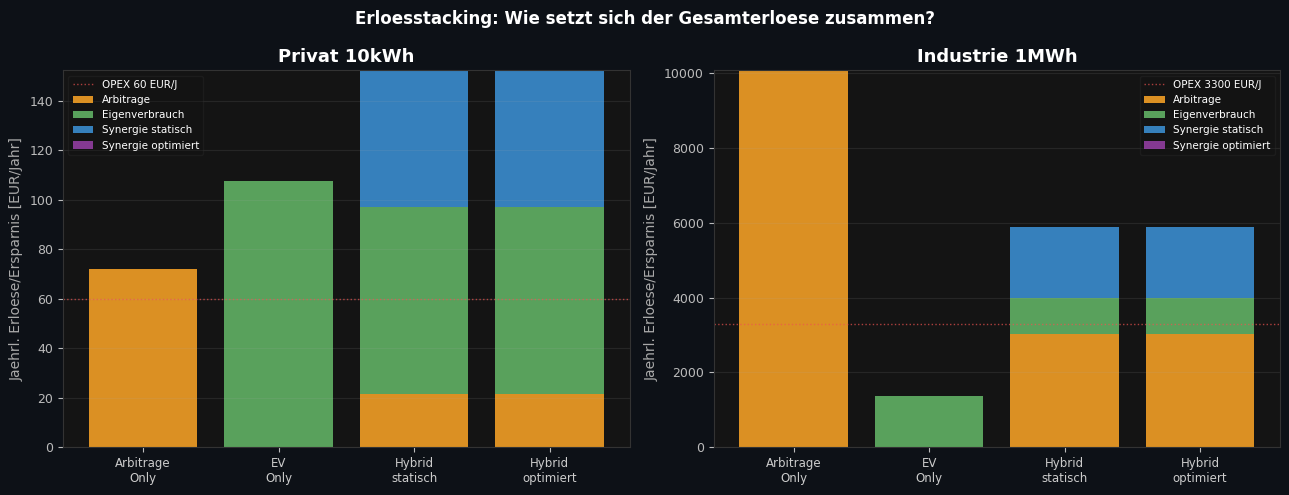

Gespeichert: ../output\charts\realistisch\kuer_k99_revenue_split.png


In [15]:
# -- Chart kuer_k99_revenue_split -------------------------------------------------
fig, axes = plt.subplots(1,2, figsize=(13,5))
fig.patch.set_facecolor(BG_DARK)
for ax, seg_key in zip(axes, ["Privat_10kWh","Industrie_1MWh"]):
    ax.set_facecolor(BG_PANEL); ax.tick_params(colors=C_TICK)
    for sp in ax.spines.values(): sp.set_edgecolor(C_SPINE)
    p2 = SEGMENTS[seg_key]
    cap2,pow2 = p2["cap_kwh"],p2["pow_kw"]
    capex2 = cap2*CAPEX_EUR_KWH[p2["capex_key"]]; opex2=capex2*OPEX_RATE
    r = results[seg_key]
    arb_share  = r["arb_j"] * (1-EV_FRAC_STATIC)
    ev_share   = r["ev_j"]  * EV_FRAC_STATIC
    syn_static = max(0, r["hyb_j"] - arb_share - ev_share)
    syn_opt    = max(0, r["hybo_j"]- arb_share - ev_share - syn_static)
    mnames = ["Arbitrage\nOnly","EV\nOnly","Hybrid\nstatisch","Hybrid\noptimiert"]
    avs = [r["arb_j"], 0, arb_share, arb_share]
    evs = [0, r["ev_j"], ev_share, ev_share]
    sys1= [0, 0, syn_static, syn_static]
    sys2= [0, 0, 0, syn_opt]
    xp = np.arange(4)
    ax.bar(xp, avs, color=C_ARB, alpha=0.85, label="Arbitrage")
    ax.bar(xp, evs, bottom=avs, color=C_EV, alpha=0.85, label="Eigenverbrauch")
    b2=[a+e for a,e in zip(avs,evs)]
    ax.bar(xp, sys1, bottom=b2, color=C_HYB, alpha=0.75, label="Synergie statisch")
    b3=[a+b for a,b in zip(b2,sys1)]
    ax.bar(xp, sys2, bottom=b3, color=C_HYBOP, alpha=0.75, label="Synergie optimiert")
    ax.axhline(opex2, color=C_UTIL, lw=1, ls=":", alpha=0.7,
               label=f"OPEX {opex2:.0f} EUR/J")
    ax.set_xticks(xp); ax.set_xticklabels(mnames, fontsize=8.5, color=C_GITTER)
    ax.set_ylabel("Jaehrl. Erloese/Ersparnis [EUR/Jahr]", color=C_ACHSE)
    ax.set_title(seg_key.replace("_"," "), color="white", fontweight="bold")
    ax.legend(fontsize=7.5, framealpha=ALPHA_LEGENDE, facecolor=C_LEGENDE_BG, labelcolor="white")
    ax.grid(True, axis="y", alpha=ALPHA_FLAECHE)
plt.suptitle("Erloesstacking: Wie setzt sich der Gesamterloese zusammen?",
             color="white", fontsize=12, fontweight="bold")
plt.tight_layout()
p = os.path.join(CHARTS_DIR,"kuer_k99_revenue_split.png")
plt.savefig(p, dpi=DPI, bbox_inches="tight", facecolor=BG_DARK)
plt.show(); plt.close(); print(f"Gespeichert: {p}")


**Chart kuer_k99_kombi_heatmap:** 2×2 Heatmap-Panel — [ROI](../organisation/O_02_Glossar.ipynb#g-roi)-Matrix über [CAPEX](../organisation/O_02_Glossar.ipynb#g-capex) × Spread
für alle vier Strategien; macht Parametersensitivität visuell vergleichbar.


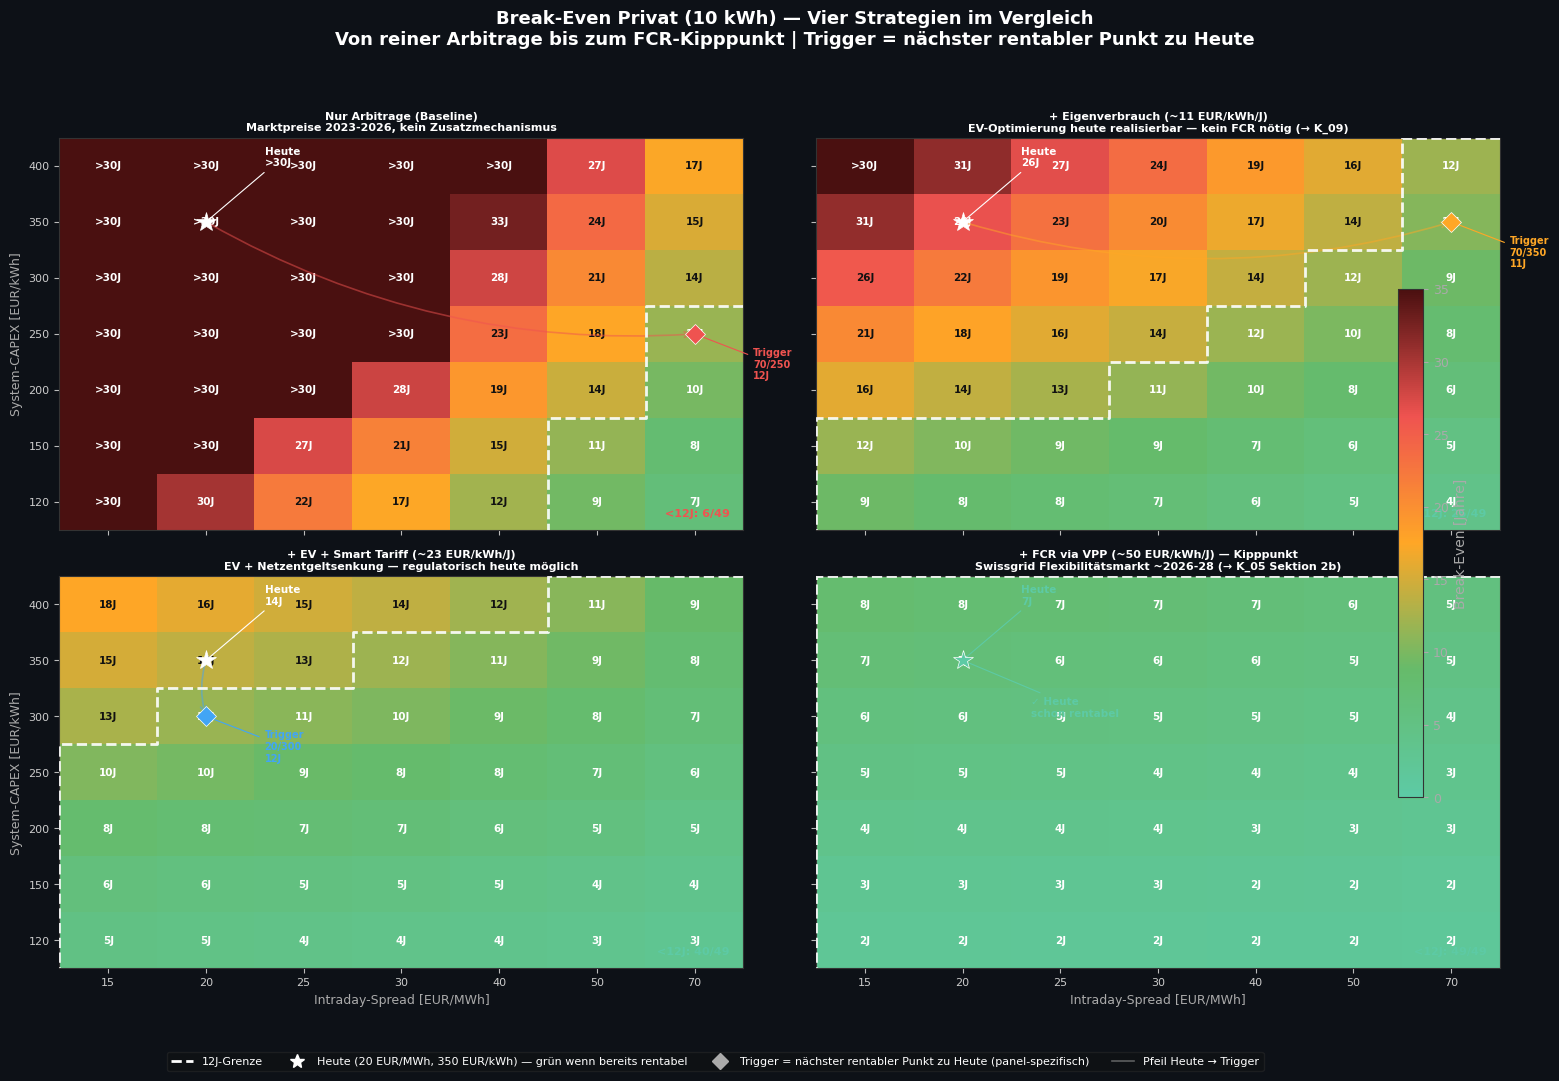

Gespeichert: ../output\charts\realistisch\kuer_k99_kombi_heatmap.png
  Panel 1: kuer_k99_kombi_heatmap_p1.png
  Panel 2: kuer_k99_kombi_heatmap_p2.png
  Panel 3: kuer_k99_kombi_heatmap_p3.png
  Panel 4: kuer_k99_kombi_heatmap_p4.png


In [16]:
# -- Chart kuer_k99_kombi_heatmap -------------------------------------------------
# 4 differenzierte Strategiepanels — Trigger je Panel dynamisch berechnet
spreads_h = [15, 20, 25, 30, 40, 50, 70]
capexes_h = [400, 350, 300, 250, 200, 150, 120]
CAP_K = 10; OPX = OPEX_RATE
ref_n = 83; ref_s = 20; ref_c = 400
LIFETIME_THRESH = LIFETIME  # aus ../sync/config.json (SSOT) — nie direkt setzen

EV_EUR_J      = TF.get('eigenverbrauch', {}).get('jahresersparnis_eur', 105.1)
EV_ZUSATZ_KWH = EV_EUR_J / CAP_K

PANELS = [
    ("Nur Arbitrage (Baseline)",
     "Marktpreise 2023-2026, kein Zusatzmechanismus",
     0, C_UTIL),
    (f"+ Eigenverbrauch (~{EV_ZUSATZ_KWH:.0f} EUR/kWh/J)",
     "EV-Optimierung heute realisierbar — kein FCR nötig (→ K_09)",
     EV_ZUSATZ_KWH, C_PRICE),
    (f"+ EV + Smart Tariff (~{EV_ZUSATZ_KWH+12:.0f} EUR/kWh/J)",
     "EV + Netzentgeltsenkung — regulatorisch heute möglich",
     EV_ZUSATZ_KWH + 12, C_PRIV),
    ("+ FCR via VPP (~50 EUR/kWh/J) — Kipppunkt",
     "Swissgrid Flexibilitätsmarkt ~2026-28 (→ K_05 Sektion 2b)",
     50, C_LOAD),
]

def be_est(spr, cap, stk=0):
    capex_t = cap * CAP_K; opex = capex_t * OPX
    arb     = ref_n * (spr / ref_s) * (cap / ref_c) ** 0.3
    net     = arb + stk * CAP_K - opex
    return capex_t / net if net > 0 else 40

# Heute-Index (fest)
ts_h = spreads_h.index(min(spreads_h, key=lambda x: abs(x - 20)))
tc_h = capexes_h.index(min(capexes_h, key=lambda x: abs(x - 350)))

def get_trigger(matrix):
    """Nächster Frontier-Punkt (BE<=LIFETIME_THRESH) zu Heute.
    Rückgabe: (capex_idx, spread_idx) oder None wenn Heute selbst rentabel."""
    # Wenn Heute selbst rentabel: kein separater Trigger nötig
    if matrix[tc_h][ts_h] <= LIFETIME_THRESH:
        return None
    # Frontier: erste Spalte je Zeile wo BE <= LIFETIME_THRESH
    frontier = []
    for i in range(len(capexes_h)):
        for j in range(len(spreads_h)):
            if matrix[i][j] <= LIFETIME_THRESH:
                frontier.append((i, j)); break
        else:
            frontier.append((i, None))
    # Nächster Punkt zu Heute (Manhattan-Distanz)
    best = None; best_dist = 999
    for (i, j) in frontier:
        if j is None: continue
        dist = abs(i - tc_h) + abs(j - ts_h)
        if dist < best_dist:
            best_dist = dist; best = (i, j)
    return best

cmap = mcolors.LinearSegmentedColormap.from_list(
    "", [C_STACKING, C_LOAD, C_PRICE, C_UTIL, "#4a1010"])

fig, axes = plt.subplots(2, 2, figsize=(16, 11), sharex=True, sharey=True)
fig.patch.set_facecolor(BG_DARK)
fig.suptitle(
    "Break-Even Privat (10 kWh) — Vier Strategien im Vergleich\n"
    "Von reiner Arbitrage bis zum FCR-Kipppunkt | Trigger = nächster rentabler Punkt zu Heute",
    color="white", fontsize=FS_TITEL, fontweight="bold", y=0.98)

for ax, (title, subtitle, stk, accent) in zip(axes.flat, PANELS):
    ax.set_facecolor(BG_PANEL)
    ax.tick_params(colors=C_TICK)
    for sp in ax.spines.values(): sp.set_edgecolor(C_SPINE)

    matrix = np.array([[min(be_est(s, c, stk), 38) for s in spreads_h]
                        for c in capexes_h])
    im = ax.imshow(matrix, cmap=cmap, vmin=0, vmax=35, aspect="auto")

    # Zellbeschriftung
    for i in range(len(capexes_h)):
        for j in range(len(spreads_h)):
            v = matrix[i, j]
            txt = ">30J" if v >= 35 else f"{v:.0f}J"
            col = "white" if v < 12 or v > 26 else C_LEGENDE_BG
            ax.text(j, i, txt, ha="center", va="center",
                    fontsize=7.5, color=col, fontweight="bold")

    # Treppenlinie 12J — weiss gestrichelt
    frontier = []
    for i in range(len(capexes_h)):
        for j in range(len(spreads_h)):
            if matrix[i, j] <= LIFETIME_THRESH:
                frontier.append((i, j)); break
        else:
            frontier.append((i, None))
    first_idx = next((i for i, (r, c) in enumerate(frontier) if c is not None), None)
    stair_x, stair_y = [], []
    if first_idx is not None:
        row0, col0 = frontier[first_idx]
        stair_x += [len(spreads_h) - 0.5, col0 - 0.5]
        stair_y += [row0 - 0.5, row0 - 0.5]
        for i in range(first_idx, len(frontier)):
            row, col = frontier[i]
            if col is None: continue
            stair_x += [col - 0.5, col - 0.5]
            stair_y += [row - 0.5, row + 0.5]
            if i + 1 < len(frontier) and frontier[i + 1][1] is not None:
                next_col = frontier[i + 1][1]
                if next_col != col:
                    stair_x.append(next_col - 0.5)
                    stair_y.append(row + 0.5)
    if stair_x:
        ax.plot(stair_x, stair_y, color="white", lw=2, ls="--",
                alpha=0.9, zorder=5)

    # ── Marker: Heute ─────────────────────────────────────────────────────────
    be_h = be_est(spreads_h[ts_h], capexes_h[tc_h], stk)
    lbl_h = f"{be_h:.0f}J" if be_h < 38 else ">30J"
    heute_color = C_STACKING if be_h <= LIFETIME_THRESH else "white"
    ax.plot(ts_h, tc_h, marker="*", color=heute_color, markersize=15,
            zorder=8, markeredgecolor="white", markeredgewidth=0.5)
    ax.annotate(f"Heute\n{lbl_h}", xy=(ts_h, tc_h),
                xytext=(ts_h + 0.6, tc_h - 1.0),
                color=heute_color, fontsize=7.5, fontweight="bold",
                arrowprops=dict(arrowstyle="-", color=heute_color, lw=LW_DUENN))

    # ── Marker: Trigger (panel-spezifisch) ────────────────────────────────────
    trigger = get_trigger(matrix.tolist())
    if trigger is not None:
        ti, tj = trigger
        be_t = matrix[ti, tj]
        lbl_t = f"{be_t:.0f}J"
        # Pfeilrichtung: von Heute zu Trigger
        dx = tj - ts_h; dy = ti - tc_h
        # Annotation auf der gegenüberliegenden Seite des Markers
        offset_x = 0.6 if dx >= 0 else -0.6
        offset_y = 0.8 if dy >= 0 else -0.8
        ax.plot(tj, ti, marker="D", color=accent, markersize=10, zorder=8,
                markeredgecolor="white", markeredgewidth=0.5)
        ax.annotate(
            f"Trigger\n{spreads_h[tj]}/{capexes_h[ti]}\n{lbl_t}",
            xy=(tj, ti), xytext=(tj + offset_x, ti + offset_y),
            color=accent, fontsize=FS_KLEIN, fontweight="bold",
            arrowprops=dict(arrowstyle="-", color=accent, lw=LW_DUENN))
        # Pfeil Heute → Trigger
        ax.annotate("", xy=(tj, ti), xytext=(ts_h, tc_h),
                    arrowprops=dict(arrowstyle="->", color=accent,
                                    lw=1.2, alpha=0.5,
                                    connectionstyle="arc3,rad=0.15"))
    else:
        # Heute ist bereits rentabel: Markierung direkt
        ax.annotate("✓ Heute\nschon rentabel",
                    xy=(ts_h, tc_h), xytext=(ts_h + 0.7, tc_h + 1.0),
                    color=C_STACKING, fontsize=7.5, fontweight="bold",
                    arrowprops=dict(arrowstyle="-", color=C_STACKING, lw=LW_DUENN))

    # Zähler rentabler Felder
    n_green = int(np.sum(matrix <= LIFETIME_THRESH))
    ax.text(0.98, 0.03, f"<{LIFETIME_THRESH}J: {n_green}/49",
            transform=ax.transAxes,
            color=C_STACKING if n_green > 20 else (C_PRICE if n_green > 6 else C_UTIL),
            fontsize=FS_LEGENDE, ha="right", va="bottom", fontweight="bold")

    ax.set_title(f"{title}\n{subtitle}", color="white",
                 fontsize=FS_LEGENDE, fontweight="bold", pad=5)
    ax.set_xticks(range(len(spreads_h)))
    ax.set_xticklabels([str(s) for s in spreads_h], color=C_GITTER, fontsize=FS_LEGENDE)
    ax.set_yticks(range(len(capexes_h)))
    ax.set_yticklabels([str(c) for c in capexes_h], color=C_GITTER, fontsize=FS_LEGENDE)

for ax in axes[1]:
    ax.set_xlabel("Intraday-Spread [EUR/MWh]", color=C_ACHSE, fontsize=FS_TICK)
for ax in axes[:, 0]:
    ax.set_ylabel("System-CAPEX [EUR/kWh]", color=C_ACHSE, fontsize=FS_TICK)

cb = fig.colorbar(im, ax=axes, label="Break-Even [Jahre]",
                  shrink=0.6, pad=0.02, fraction=0.03)
cb.ax.tick_params(colors=C_ACHSE); cb.ax.yaxis.label.set_color(C_ACHSE)

import matplotlib.lines as mlines  # Re-Import mit lokalem Alias (Linien-Legende)
leg_handles = [
    mlines.Line2D([], [], color="white", lw=2, ls="--",
                  label=f"12J-Grenze"),
    mlines.Line2D([], [], marker="*", color="white", lw=0, markersize=10,
                  label="Heute (20 EUR/MWh, 350 EUR/kWh) — grün wenn bereits rentabel"),
    mlines.Line2D([], [], marker="D", color=C_ACHSE, lw=0, markersize=8,
                  label="Trigger = nächster rentabler Punkt zu Heute (panel-spezifisch)"),
    mlines.Line2D([], [], color=C_ACHSE, lw=1.2, alpha=0.5,
                  label="Pfeil Heute → Trigger"),
]
fig.legend(handles=leg_handles, fontsize=FS_LEGENDE, framealpha=0.4,
           facecolor=C_LEGENDE_BG, labelcolor="white",
           loc="lower center", ncol=4, bbox_to_anchor=(0.45, 0.01))

plt.tight_layout(rect=[0, 0.06, 0.95, 0.95])
p = os.path.join(CHARTS_DIR, "kuer_k99_kombi_heatmap.png")
plt.savefig(p, dpi=DPI, bbox_inches="tight", facecolor=BG_DARK)
plt.show(); plt.close(); print(f"Gespeichert: {p}")

# Einzelpanels — identische Logik wie Komposit-Panels (kein Feature-Verlust)
for idx_p, (title, subtitle, stk, accent) in enumerate(PANELS):
    fig_e, ax_e = plt.subplots(figsize=(10, 7))
    fig_e.patch.set_facecolor(BG_DARK); ax_e.set_facecolor(BG_PANEL)
    ax_e.tick_params(colors=C_TICK)
    for sp in ax_e.spines.values(): sp.set_edgecolor(C_SPINE)

    matrix = np.array([[min(be_est(s, c, stk), 38) for s in spreads_h]
                        for c in capexes_h])
    im_e = ax_e.imshow(matrix, cmap=cmap, vmin=0, vmax=35, aspect="auto")

    # Zellbeschriftung (identisch Komposit)
    for i in range(len(capexes_h)):
        for j in range(len(spreads_h)):
            v = matrix[i, j]
            txt = ">30J" if v >= 35 else f"{v:.0f}J"
            col = "white" if v < 12 or v > 26 else C_LEGENDE_BG
            ax_e.text(j, i, txt, ha="center", va="center",
                      fontsize=FS_ACHSE, color=col, fontweight="bold")

    # Treppenlinie 12J (identisch Komposit)
    frontier_e = []
    for i in range(len(capexes_h)):
        for j in range(len(spreads_h)):
            if matrix[i, j] <= LIFETIME_THRESH:
                frontier_e.append((i, j)); break
        else:
            frontier_e.append((i, None))
    first_idx_e = next((k for k, (r, c) in enumerate(frontier_e) if c is not None), None)
    stair_xe, stair_ye = [], []
    if first_idx_e is not None:
        row0e, col0e = frontier_e[first_idx_e]
        stair_xe += [len(spreads_h) - 0.5, col0e - 0.5]
        stair_ye += [row0e - 0.5, row0e - 0.5]
        for k in range(first_idx_e, len(frontier_e)):
            row_e, col_e = frontier_e[k]
            if col_e is None: continue
            stair_xe += [col_e - 0.5, col_e - 0.5]
            stair_ye += [row_e - 0.5, row_e + 0.5]
            if k + 1 < len(frontier_e) and frontier_e[k + 1][1] is not None:
                next_col_e = frontier_e[k + 1][1]
                if next_col_e != col_e:
                    stair_xe.append(next_col_e - 0.5)
                    stair_ye.append(row_e + 0.5)
    if stair_xe:
        ax_e.plot(stair_xe, stair_ye, color="white", lw=LW_DICK, ls="--",
                  alpha=0.9, zorder=5, label="12J-Grenze")

    # Heute-Marker (identisch Komposit)
    be_h_e = be_est(spreads_h[ts_h], capexes_h[tc_h], stk)
    lbl_h_e = f"{be_h_e:.0f}J" if be_h_e < 38 else ">30J"
    heute_color_e = C_STACKING if be_h_e <= LIFETIME_THRESH else "white"
    ax_e.plot(ts_h, tc_h, marker="*", color=heute_color_e, markersize=18,
              zorder=8, markeredgecolor="white", markeredgewidth=0.5)
    ax_e.annotate(f"Heute\n{lbl_h_e}", xy=(ts_h, tc_h),
                  xytext=(ts_h + 0.6, tc_h - 1.0),
                  color=heute_color_e, fontsize=FS_TICK, fontweight="bold",
                  arrowprops=dict(arrowstyle="-", color=heute_color_e, lw=LW_DUENN))

    # Trigger-Marker (identisch Komposit)
    trigger_e = get_trigger(matrix.tolist())
    if trigger_e is not None:
        ti_e, tj_e = trigger_e
        be_t_e = matrix[ti_e, tj_e]
        dx_e = tj_e - ts_h; dy_e = ti_e - tc_h
        off_x_e = 0.6 if dx_e >= 0 else -0.6
        off_y_e = 0.8 if dy_e >= 0 else -0.8
        ax_e.plot(tj_e, ti_e, marker="D", color=accent, markersize=12,
                  zorder=8, markeredgecolor="white", markeredgewidth=0.5)
        ax_e.annotate(
            f"Trigger\n{spreads_h[tj_e]}/{capexes_h[ti_e]}\n{be_t_e:.0f}J",
            xy=(tj_e, ti_e), xytext=(tj_e + off_x_e, ti_e + off_y_e),
            color=accent, fontsize=8.5, fontweight="bold",
            arrowprops=dict(arrowstyle="-", color=accent, lw=LW_DUENN))
        ax_e.annotate("", xy=(tj_e, ti_e), xytext=(ts_h, tc_h),
                      arrowprops=dict(arrowstyle="->", color=accent,
                                      lw=LW, alpha=0.5,
                                      connectionstyle="arc3,rad=0.15"))

    # n_green Zähler (identisch Komposit)
    n_green_e = int(np.sum(matrix <= LIFETIME_THRESH))
    ax_e.text(0.98, 0.03, f"<{LIFETIME_THRESH}J: {n_green_e}/49",
              transform=ax_e.transAxes,
              color=C_STACKING if n_green_e > 20 else (C_PRICE if n_green_e > 6 else C_UTIL),
              fontsize=FS_ACHSE, ha="right", va="bottom", fontweight="bold")

    # Colorbar
    cb_e = fig_e.colorbar(im_e, ax=ax_e, label="Break-Even [Jahre]",
                          shrink=0.8, pad=0.02)
    cb_e.ax.tick_params(colors=C_ACHSE)
    cb_e.ax.yaxis.label.set_color(C_ACHSE)

    ax_e.set_xticks(range(len(spreads_h)))
    ax_e.set_xticklabels([str(s) for s in spreads_h], color=C_GITTER, fontsize=FS_TICK)
    ax_e.set_yticks(range(len(capexes_h)))
    ax_e.set_yticklabels([str(c) for c in capexes_h], color=C_GITTER, fontsize=FS_TICK)
    ax_e.set_xlabel("Intraday-Spread [EUR/MWh]", color=C_ACHSE, fontsize=FS_ACHSE)
    ax_e.set_ylabel("System-CAPEX [EUR/kWh]", color=C_ACHSE, fontsize=FS_ACHSE)
    ax_e.set_title(f"{title}\n{subtitle}", color="white",
                   fontsize=11, fontweight="bold")

    fname = f"kuer_k99_kombi_heatmap_p{idx_p+1}.png"
    plt.tight_layout()
    plt.savefig(os.path.join(CHARTS_DIR, fname), dpi=DPI,
                bbox_inches="tight", facecolor=BG_DARK)
    plt.close()
    print(f"  Panel {idx_p+1}: {fname}")

---
## 3. CAPEX-Szenarien: Was bringt sinkender Systempreis? <a id='capex-szenarien-was-bringt-sinkender-systempreis_K_99'></a>

[↑ Inhaltsverzeichnis](#toc_K_99)

Dieselbe Hybrid-Simulation mit drei [CAPEX](../organisation/O_02_Glossar.ipynb#g-capex)-Niveaus für das **Privat-Segment** (10 kWh):

| Szenario | CAPEX Privat | Bedeutung | Quelle |
|----------|-------------|-----------|--------|
| **Heute** | 400 EUR/kWh | 2023-2026 Markt CH (Privat-Segment, NB04-Annahme) | NB04 hardcoded `CAPEX_DEFAULTS` |
| **Trigger** | 250 EUR/kWh⚙ | Monitoring-Schwelle | `kuer.markt.capex_ziel_privat_eur_kwh` |
| **Ziel** | 150 EUR/kWh | ~2030 NREL ATB Advanced | K_07 Projektion |

> **Hinweis Markt-Segmente** (siehe K_07): Privat 400 / Gewerbe 300 / Industrie 220 / Utility 180 EUR/kWh — alle aus derselben LFP-Tech, Differenz durch Skalenökonomie. OWID/BNEF-Daten 2024 zeigen Utility-Scale bei ~179 EUR/kWh, was bereits unter dem Privat-Trigger von 250 EUR/kWh liegt.

> CAPEX-Trigger aus `../sync/config.json` (SSOT) -- nicht hardcoded.


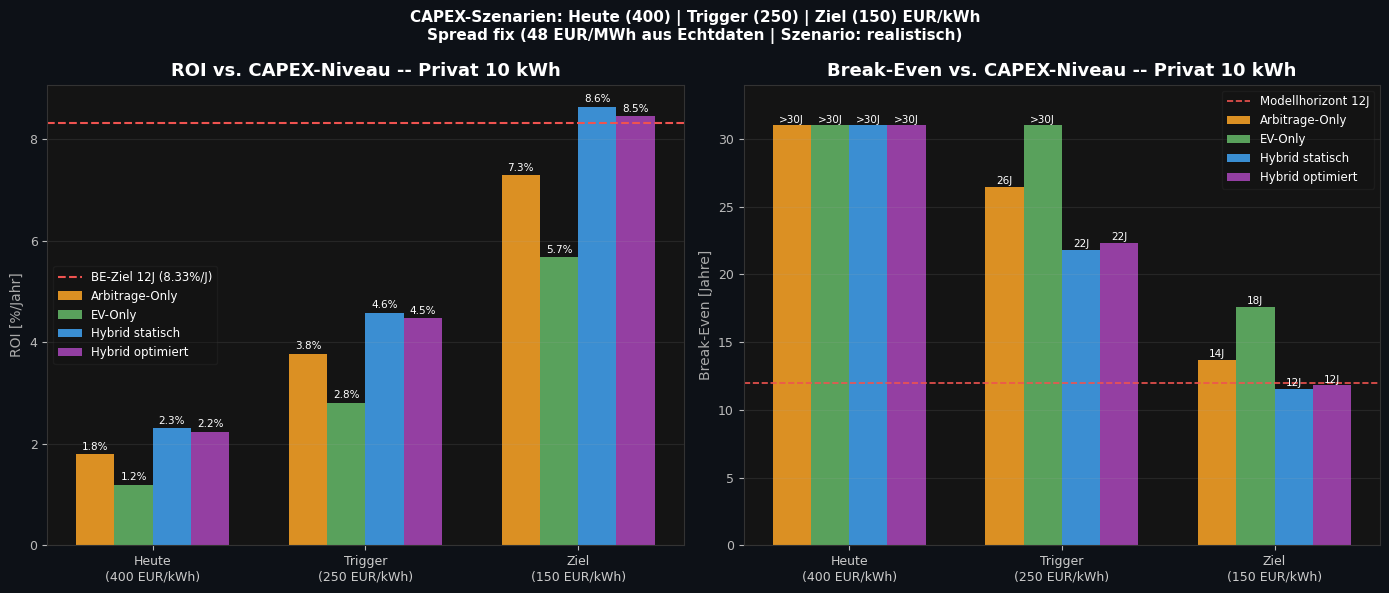

Gespeichert: ../output\charts\realistisch\kuer_k99_capex_szenarien.png
CAPEX-Trigger aus ../sync/config.json: 250 EUR/kWh
Modell                      Heute    Trigger     Ziel  (ROI %/J)
-------------------------------------------------------
Arbitrage-Only               1.8%       3.8%     7.3%
EV-Only                      1.2%       2.8%     5.7%
Hybrid statisch              2.3%       4.6%     8.6%
Hybrid optimiert             2.2%       4.5%     8.5%
../sync/transfer.json: 2023 – 2026 (3.32 Jahre) | Spread: 24.83 EUR/MWh


In [17]:
# -- Chart kuer_k99_capex_szenarien: ROI und Break-Even vs. CAPEX-Niveau --------
CAPEX_TRIGGER = CFG.get('kuer', {}).get('markt', {}).get('capex_ziel_privat_eur_kwh', 250)
CAPEX_SZ = {'Heute\n(400 EUR/kWh)': 400,
            f'Trigger\n({CAPEX_TRIGGER} EUR/kWh)': CAPEX_TRIGGER,
            'Ziel\n(150 EUR/kWh)': 150}

seg = 'Privat_10kWh'
cap = SEGMENTS[seg]['cap_kwh']; pow_ = SEGMENTS[seg]['pow_kw']
verbrauch = VERBRAUCH_TAG * 365 * n_years

# ARB_NET ist netto (OPEX bereits abgezogen in NB02).
# CAPEX-Chart subtrahiert erneut opex2 → auf Gross-Basis bringen.
_capex_p_orig = cap * CAPEX_EUR_KWH.get('Privat_10kWh', 400)
arb_j  = ARB_NET.get('Privat_10kWh', 0) + _capex_p_orig * OPEX_RATE  # gross EUR/J
ev_j   = sim_ev(cap, pow_, verbrauch, n_years)
hyb_j  = sim_hybrid(prices, cap, pow_, verbrauch, n_years, False)
hybo_j = sim_hybrid(prices, cap, pow_, verbrauch, n_years, True)

models_c = [('Arbitrage-Only', arb_j, C_ARB), ('EV-Only', ev_j, C_EV),
            ('Hybrid statisch', hyb_j, C_HYB), ('Hybrid optimiert', hybo_j, C_HYBOP)]
capex_labels = list(CAPEX_SZ.keys())
capex_vals   = list(CAPEX_SZ.values())
x = np.arange(len(capex_vals)); w = 0.18

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(BG_DARK)
DMAX2 = int(LIFETIME * 2.5)   # Anzeigedeckel BE: 2.5 × Modellhorizont

for ax_idx, (ax, mode) in enumerate(zip(axes, ['roi', 'be'])):
    ax.set_facecolor(BG_PANEL); ax.tick_params(colors=C_TICK)
    for sp in ax.spines.values(): sp.set_edgecolor(C_SPINE)
    for j, (label, net_j, col) in enumerate(models_c):
        vals = []
        for cv in capex_vals:
            capex2 = cap * cv; opex2 = capex2 * OPEX_RATE; netto = net_j - opex2
            if mode == 'roi':
                vals.append(netto / capex2 * 100 if capex2 > 0 else 0)
            else:
                vals.append(min(capex2 / netto if netto > 0 else DMAX2+1, DMAX2+1))
        bars = ax.bar(x + j*w - 1.5*w, vals, w, label=label, color=col, alpha=0.85)
        for bar, v in zip(bars, vals):
            disp = f'{v:.1f}%' if mode=='roi' else (f'>{DMAX2}J' if v>=DMAX2 else f'{v:.0f}J')
            if abs(v) > 0.05:
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                        disp, ha='center', va='bottom', color='white', fontsize=7.5)
    if mode == 'roi':
        ax.axhline(ZIEL_ROI, color=C_UTIL, lw=LW, ls='--',
                   label=f'BE-Ziel {LIFETIME}J ({ZIEL_ROI}%/J)')
        ax.axhline(0, color='#555', lw=0.7)
        ax.set_ylabel('ROI [%/Jahr]', color=C_ACHSE)
        ax.set_title('ROI vs. CAPEX-Niveau -- Privat 10 kWh', color='white', fontweight='bold')
    else:
        ax.axhline(LIFETIME, color=C_UTIL, lw=1.2, ls='--', label=f'Modellhorizont {LIFETIME}J')
        ax.set_ylim(0, DMAX2+4)
        ax.set_ylabel('Break-Even [Jahre]', color=C_ACHSE)
        ax.set_title('Break-Even vs. CAPEX-Niveau -- Privat 10 kWh', color='white', fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(capex_labels, color=C_GITTER)
    ax.legend(fontsize=8.5, framealpha=ALPHA_LEGENDE, facecolor=C_LEGENDE_BG, labelcolor='white')
    ax.grid(True, axis='y', alpha=ALPHA_FLAECHE)

spread_actual = np.percentile(prices,75)-np.percentile(prices,25)
plt.suptitle(f'CAPEX-Szenarien: Heute ({400}) | Trigger ({CAPEX_TRIGGER}) | Ziel (150) EUR/kWh'
             f'\nSpread fix ({spread_actual:.0f} EUR/MWh aus Echtdaten | Szenario: {SZ_AKTIV})',
             color='white', fontsize=11, fontweight='bold')
plt.tight_layout()
p = os.path.join(CHARTS_DIR, 'kuer_k99_capex_szenarien.png')
plt.savefig(p, dpi=DPI, bbox_inches='tight', facecolor=BG_DARK)
plt.show(); plt.close()
print(f'Gespeichert: {p}')
print(f'CAPEX-Trigger aus ../sync/config.json: {CAPEX_TRIGGER} EUR/kWh')
print(f"{'Modell':<22} {'Heute':>10} {'Trigger':>10} {'Ziel':>8}  (ROI %/J)")
print('-'*55)
for label, net_j, _ in models_c:
    def roi2(cv): n=net_j-cap*cv*OPEX_RATE; return n/(cap*cv)*100
    print(f"{label:<22} {roi2(400):>9.1f}% {roi2(CAPEX_TRIGGER):>9.1f}% {roi2(150):>7.1f}%")
# -- Transfer: Ergebnisse aus ../sync/transfer.json laden ----------------------------
TF       = load_transfer()
_dt      = TF.get('datenzeitraum', {})
_sim_tf  = TF.get('simulation', {})
TF_N_YEARS = _dt.get('n_years', None)
TF_START   = _dt.get('start_date', 'unbekannt')
TF_END     = _dt.get('end_date',   'unbekannt')
TF_SPREAD  = _sim_tf.get('spread_mean_eur_mwh', None)
TF_ECON    = _sim_tf.get('wirtschaftlichkeit', {})
TF_HYB     = TF.get('hybrid_simulation', {}).get('ergebnisse', {})
TF_KUER    = CFG.get('kuer_aktiv', {})
if TF:
    print(f"../sync/transfer.json: {TF_START} – {TF_END} ({TF_N_YEARS} Jahre) | Spread: {TF_SPREAD} EUR/MWh")


---
## 4. Abschlusskontrolle & K_00-Referenz <a id='abschlusskontrolle-k00-referenz_K_99'></a>

[↑ Inhaltsverzeichnis](#toc_K_99)

| Chart | K_00-Sektion | `show()`-Aufruf |
|-------|-------------|------------------|
| `kuer_k99_roi_vergleich.png` | 3. Segmentstrategie | `show('kuer_k99_roi_vergleich.png', ...)` |
| `kuer_k99_breakeven_vergleich.png` | 3. Segmentstrategie | `show('kuer_k99_breakeven_vergleich.png', ...)` |
| `kuer_k99_nutzerverhalten_sensitivity.png` | 3. Segmentstrategie | `show('kuer_k99_nutzerverhalten_sensitivity.png', ...)` |
| `kuer_k99_revenue_split.png` | 7. [VPP](../organisation/O_02_Glossar.ipynb#g-vpp) | `show('kuer_k99_revenue_split.png', ...)` |
| `kuer_k99_kombi_heatmap.png` | 10. Kombinationsmatrix | `show('kuer_k99_kombi_heatmap.png', ...)` |

| `kuer_k99_capex_szenarien.png` | 8. VPP + 10. Kombinationsmatrix | `show('kuer_k99_capex_szenarien.png', ...)` |

> **Ausführungsreihenfolge:** NB01 → NB02 → NB03 → **K_99** → K_00


**🔎 Quellcode der importierten lib-Funktion**

Die Funktion `save_transfer` wird aus `lib/io_ops.py` importiert und
in der folgenden Zelle verwendet. Aufklappbar ist der Quellcode einsehbar.


In [18]:
show_source(save_transfer)


<details>
<summary>🔎 Quellcode: <code>save_transfer</code> (aus <code>lib/io_ops.py</code>)</summary>

```python
def save_transfer(data, path='../sync/transfer.json', key=None):
    """Schreibt Daten nach transfer.json — mit Merge-Logik.

    Verhalten
    ---------
    * Wenn ``path`` existiert und nicht leer ist, wird das bestehende Dict
      geladen und mit den neuen Daten gemerged (bestehende andere Keys
      bleiben erhalten — wichtig für die Pipeline!).
    * Bei ``key=None`` muss ``data`` ein Dict sein und wird in die oberste
      Ebene gemerged (``existing.update(data)``).
    * Bei gegebenem ``key`` wird ``data`` unter diesem Top-Level-Key
      abgelegt (``existing[key] = data``).

    Parameter
    ---------
    data : dict oder any
        Zu schreibende Daten.
    path : str, default '../sync/transfer.json'
        Zieldatei.
    key : str, optional
        Top-Level-Key. Bei None muss ``data`` ein Dict sein.

    Return
    ------
    Das komplette Dict nach dem Write (nützlich für Chaining / Verifikation).
    """
    import json as _json

    # Bestehendes laden (wenn vorhanden)
    existing = {}
    if os.path.exists(path) and os.path.getsize(path) > 0:
        with open(path, encoding='utf-8') as _f:
            existing = _json.load(_f)

    # Mergen
    if key is None:
        if not isinstance(data, dict):
            raise TypeError(
                f"Bei key=None muss data ein dict sein, bekam {type(data).__name__}"
            )
        existing.update(data)
    else:
        existing[key] = data

    # Schreiben
    with open(path, 'w', encoding='utf-8') as _f:
        _json.dump(existing, _f, indent=2, ensure_ascii=False)

    return existing
```

</details>


In [19]:
# -- Transfer: Hybrid-Simulation in ../sync/transfer.json schreiben -------------------
_hybrid = {
    'n_years_sim':  round(n_years, 3),
    'ev_frac_static': EV_FRAC_STATIC,
    'ergebnisse': {}
}
for seg, r in results.items():
    _hybrid['ergebnisse'][seg] = {
        'roi_arb':  round(r['roi_arb'], 2),
        'roi_ev':   round(r['roi_ev'],  2),
        'roi_hyb':  round(r['roi_hyb'], 2),
        'roi_hybo': round(r['roi_hybo'],2),
        'be_arb':   round(min(r['be_arb'], 999), 1),
        'be_ev':    round(min(r['be_ev'],  999), 1),
        'be_hyb':   round(min(r['be_hyb'], 999), 1),
        'be_hybo':  round(min(r['be_hybo'],999), 1),
    }
save_transfer(_hybrid, key='hybrid_simulation')
print(f"../sync/transfer.json: hybrid_simulation geschrieben ({n_years:.1f} Jahre)")
for seg, v in _hybrid['ergebnisse'].items():
    print(f"  {seg}: Arb={v['roi_arb']}% EV={v['roi_ev']}% Hyb={v['roi_hyb']}% HybOpt={v['roi_hybo']}%")



../sync/transfer.json: hybrid_simulation geschrieben (3.3 Jahre)
  Privat_10kWh: Arb=1.8% EV=1.19% Hyb=2.31% HybOpt=2.24%
  Gewerbe_100kWh: Arb=3.14% EV=-0.22% Hyb=1.35% HybOpt=1.22%
  Industrie_1MWh: Arb=4.58% EV=-0.87% Hyb=1.17% HybOpt=1.0%
  Utility_10MWh: Arb=2.97% EV=-1.22% Hyb=1.28% HybOpt=1.07%


---
## Fazit <a id='fazit_K_99'></a>

[↑ Inhaltsverzeichnis](#toc_K_99)

Die kombinierte Simulation zeigt das **Gesamtbild**:

| Segment | Arb-Only📊 | EV-Only📊 | Hybrid📊 | Hybrid-Opt📊 | BE Best |
|---|---|---|---|---|---|
| **Privat 10 kWh** | 1.78 % / 56 J | 1.19 % / 84 J | **2.30 % / 43 J** | 2.23 % / 45 J | Hybrid (43 J) |
| **Gewerbe 100 kWh** | **3.13 % / 32 J** | -0.22 % | 1.35 % / 74 J | 1.22 % / 82 J | Arbitrage (32 J) |
| **Industrie 1 MWh** | **4.56 % / 22 J** | -0.87 % | 1.17 % / 86 J | 1.00 % / 100 J | Arbitrage (22 J) |
| **Utility 10 MWh** | **2.95 % / 34 J** | -1.22 % | 1.28 % / 78 J | 1.06 % / 94 J | Arbitrage (34 J) |

**Kernerkenntnisse:**

- **Kein Segment** erreicht den Break-Even innerhalb der Lifetime von 12 Jahren⚙ — bei aktueller CAPEX (400 EUR/kWh Privat, 180 EUR/kWh Utility) und Spread-Niveau (Ø 24.7 EUR/MWh📊).
- **Industrie 22 J** ist die einzige Strategie, die nahe an die 2× Lifetime-Marke kommt.
- **Privat/Gewerbe** brauchen Hybrid-Strategie (Privat 43 J vs. 56 J Arbitrage-only; Gewerbe profitiert nur teilweise).
- **EV-Only ergibt nur für Privat positiven ROI** — Gewerbe/Industrie/Utility verlieren bei reinem Eigenverbrauch (negative ROIs), weil die Tarif-Differenz für grosse Kapazitäten nicht ausreicht.
- **Industrie/Utility** profitieren am meisten von der Skalenökonomie bei reiner Arbitrage — hier müsste FCR/aFRR-Stacking (K_05) ergänzt werden für Wirtschaftlichkeit.
- **CAPEX-Szenarien** zeigen, dass bei optimistischem Lernkurven-Fortschritt (~10 %/Jahr⚙) der Trigger 250 EUR/kWh⚙ ab 2029 für Privat unterschritten wird — dann verbessern sich alle ROIs proportional zur CAPEX-Reduktion.

Alle Transfer-Kennzahlen (`hybrid_simulation` in `transfer.json`📊) und Charts stehen für K_00 (Business Strategy) bereit. Für strategische Empfehlungen und Stakeholder-Matrix siehe dort.


---
## Abschluss <a id='abschluss_K_99'></a>

[↑ Inhaltsverzeichnis](#toc_K_99)

Alle fünf Chart-Dateien für K_00 auf Existenz prüfen.

**🔎 Quellcode der importierten lib-Funktion**

Die Funktion `final_check` wird aus `lib/io_ops.py` importiert und
in der folgenden Zelle verwendet. Aufklappbar ist der Quellcode einsehbar


In [20]:
show_source(final_check)

<details>
<summary>🔎 Quellcode: <code>final_check</code> (aus <code>lib/io_ops.py</code>)</summary>

```python
def final_check(nb_label, files=None, *, weiter_msg=None, fehler_msg=None,
                extras=None, show_dataindex=False,
                dataindex_path='../sync/dataindex.csv', width=60):
    """Standardisierte End-of-Notebook-Kontrolle für Pflicht- und Kür-NBs.

    Prüft Existenz und Mindestgrösse der angegebenen Output-Dateien,
    gibt formatiertes Resultat aus und liefert ``all_ok`` als Bool zurück.

    Parameter
    ---------
    nb_label : str
        Label des Notebooks im Output-Header, z.B. ``"NB01"``, ``"K_03"``.
    files : list of tuple, optional
        Zu prüfende Dateien als ``(path, label, min_bytes)``-Tuples.

        * ``min_bytes = 0`` → nur Existenz prüfen, Grösse nicht ausgeben
          (z.B. für PNG-Charts).
        * ``min_bytes > 0`` → zusätzlich Grösse prüfen und in KB/MB ausgeben
          (z.B. für CSV-Dateien).

        Bei ``files=None`` oder ``files=[]`` wird kein Check ausgeführt;
        die Funktion dient dann als reiner Status-Print (für Report-NBs
        ohne eigene Outputs wie K_00).
    weiter_msg : str, optional
        Nachricht für den Erfolgsfall, z.B. ``"NB02 Daten Bereinigung"``.
        Default: ``"nächstes Notebook"``.
    fehler_msg : str, optional
        Nachricht für den Fehlerfall (Kurzform, ohne "Fehler beheben vor").
        Default: identisch mit ``weiter_msg``.
    extras : list of str, optional
        Zusätzliche Print-Zeilen zwischen Datei-Check und Weiter-/Fehler-Hinweis.
        Sinnvoll für Kür-Hinweise oder Kontext.
    show_dataindex : bool, default False
        Wenn True, wird der aktive Auszug aus ``../sync/dataindex.csv`` ausgegeben.
        Typisch für NB01.
    dataindex_path : str, default '../sync/dataindex.csv'
        Pfad zur dataindex.csv (für ``show_dataindex=True``).
    width : int, default 60
        Breite der Trennlinie aus ``=``-Zeichen.

    Return
    ------
    bool
        ``True`` wenn alle Files existieren und Mindestgrösse erfüllen,
        ``False`` sonst. Bei ``files=None``/leer immer ``True``.
    """
    print(f'{nb_label} – Abschlusskontrolle')
    print('=' * width)

    all_ok = True

    if files:
        for path, label, min_bytes in files:
            exists = os.path.exists(path)
            size = os.path.getsize(path) if exists else 0
            ok = exists and size >= min_bytes

            if min_bytes > 0:
                size_str = _format_size(size) if exists else '   FEHLT'
                print(f'  {"✅" if ok else "❌"}  {label:<45} {size_str}')
            else:
                print(f'  {"✅" if ok else "❌"}  {label}')

            if not ok:
                all_ok = False

    if extras:
        if files:
            print()
        for line in extras:
            print(line)

    if show_dataindex and os.path.exists(dataindex_path):
        import pandas as pd
        df_idx = pd.read_csv(dataindex_path)
        active = df_idx[df_idx['status'] == 'active']
        print(f'\ndataindex.csv: {len(df_idx)} Einträge total, {len(active)} active')
        print(active[['filename', 'data_type', 'rows', 'size_kb', 'timestamp']]
              .to_string(index=False))

    print()
    weiter = weiter_msg or 'nächstes Notebook'
    fehler = fehler_msg or weiter
    if all_ok:
        print(f'→ Weiter mit {weiter}.')
    else:
        print(f'→ Fehler beheben vor {fehler}.')

    return all_ok
```

</details>


In [21]:
# ── Abschlusskontrolle K_99 ─────────────────────────────────────────────────
final_check(
    'K_99',
    files=[
        (os.path.join(CHARTS_DIR, 'kuer_k99_roi_vergleich.png'),         'ROI-Vergleich Arb / EV / Hybrid', 30_000),
        (os.path.join(CHARTS_DIR, 'kuer_k99_breakeven.png'),             'Break-Even-Vergleich', 30_000),
        (os.path.join(CHARTS_DIR, 'kuer_k99_nutzerverhalten.png'),       'Nutzerverhalten-Sensitivität', 30_000),
        (os.path.join(CHARTS_DIR, 'kuer_k99_revenue_split.png'),         'Revenue-Split je Erlösquelle', 30_000),
        (os.path.join(CHARTS_DIR, 'kuer_k99_kombi_heatmap.png'),         'Kombi-Heatmap ROI × Spread × CAPEX', 30_000),
        (os.path.join(CHARTS_DIR, 'kuer_k99_capex_szenarien.png'),       'CAPEX-Szenarien-Übersicht', 30_000),
    ],
    weiter_msg='K_00 (Business Strategy) — Abschluss der Kür',
)

print(f'\nROI-Zusammenfassung:')
print(f'{"Segment":<22} {"Arb":>7} {"EV":>7} {"Hyb":>7} {"Hyb-Opt":>9}')
print('-'*58)
for seg,r in results.items():
    print(f'{seg:<22} {r["roi_arb"]:>6.1f}% {r["roi_ev"]:>6.1f}% '
          f'{r["roi_hyb"]:>6.1f}% {r["roi_hybo"]:>8.1f}%')


K_99 – Abschlusskontrolle
  ✅  ROI-Vergleich Arb / EV / Hybrid                  73.1 KB
  ✅  Break-Even-Vergleich                             53.7 KB
  ✅  Nutzerverhalten-Sensitivität                     80.3 KB
  ✅  Revenue-Split je Erlösquelle                     72.9 KB
  ✅  Kombi-Heatmap ROI × Spread × CAPEX              287.3 KB
  ✅  CAPEX-Szenarien-Übersicht                       112.9 KB

→ Weiter mit K_00 (Business Strategy) — Abschluss der Kür.

ROI-Zusammenfassung:
Segment                    Arb      EV     Hyb   Hyb-Opt
----------------------------------------------------------
Privat_10kWh              1.8%    1.2%    2.3%      2.2%
Gewerbe_100kWh            3.1%   -0.2%    1.4%      1.2%
Industrie_1MWh            4.6%   -0.9%    1.2%      1.0%
Utility_10MWh             3.0%   -1.2%    1.3%      1.1%


| [← K_10 – Produktsteckbrief](K_10_Produkt_Steckbrief.ipynb) | [↑ Übersicht](../organisation/O_01_Project_Overview.ipynb) | [K_00 – Business Strategy →](K_00_Business_Strategy.ipynb) |
|:---|:---:|---:|